# Feature Scaling

[!["Open In Colab"](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mitchell-Mirano/sorix/blob/develop/docs/learn/preprocessing/01-Scalers.ipynb)
[!["Open in GitHub"](https://img.shields.io/badge/Open%20in-GitHub-black?logo=github)](https://github.com/Mitchell-Mirano/sorix/blob/develop/docs/learn/preprocessing/01-Scalers.ipynb)
[!["Open in Docs"](https://img.shields.io/badge/Open%20in-Docs-blue?logo=readthedocs)](http://127.0.0.1:8000/sorix/learn/preprocessing/01-Scalers)


Feature scaling is a crucial preprocessing step for most machine learning models. It ensures that all numerical features contribute equally to the model by transforming them into a common scale.

**sorix** provides several scalers that implement the standard `fit`, `transform`, and `fit_transform` API, consistent with other popular libraries.

## Mathematical Definitions

### 1. MinMaxScaler

The **MinMaxScaler** transforms features by scaling each feature to a given range, typically $[0, 1]$. It is very sensitive to outliers because they determine the $\min$ and $\max$ values.

$$
x' = \frac{x - \min(x)}{\max(x) - \min(x)}
$$

### 2. StandardScaler

The **StandardScaler** standardizes features by removing the mean and scaling to unit variance. 

$$
x' = \frac{x - \mu}{\sigma}
$$

### 3. RobustScaler

The **RobustScaler** is less sensitive to outliers. It removes the median and scales the data according to the Interquartile Range (IQR).

$$
x' = \frac{x - Q_2(x)}{Q_3(x) - Q_1(x)}
$$

where $Q_1$ is the 1st quartile, $Q_2$ is the median, and $Q_3$ is the 3rd quartile.

In [1]:
# Uncomment the next line and run this cell to install sorix
#!pip install 'sorix @ git+https://github.com/Mitchell-Mirano/sorix.git@develop'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sorix
from sorix.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

plt.style.use('ggplot')

# Create synthetic data: Normal distribution + heavy outliers
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=(100, 1))
outliers = np.array([[200], [250], [-50]])
X = np.vstack([data, outliers])

def plot_comparison(original, scaled, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.hist(original, bins=30, color='skyblue', edgecolor='black')
    ax1.set_title('Original Data (with outliers)')
    
    ax2.hist(scaled, bins=30, color='salmon', edgecolor='black')
    ax2.set_title(f'Scaled Data ({title})')
    plt.show()

## Visualizing MinMaxScaler

Notice how the distribution is compressed into the $[0, 1]$ interval. The outliers force the bulk of the data to occupy a very small range near 0.4.

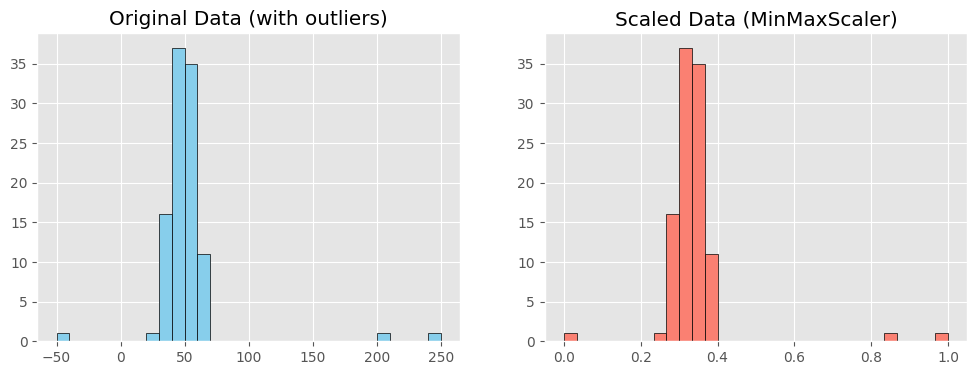

In [3]:
mms = MinMaxScaler()
X_mms = mms.fit_transform(X)
plot_comparison(X, X_mms, "MinMaxScaler")

## Visualizing StandardScaler

The mean is shifted to 0 and the standard deviation to 1. However, the outliers still influence the standard deviation calculation, spreading the data points.

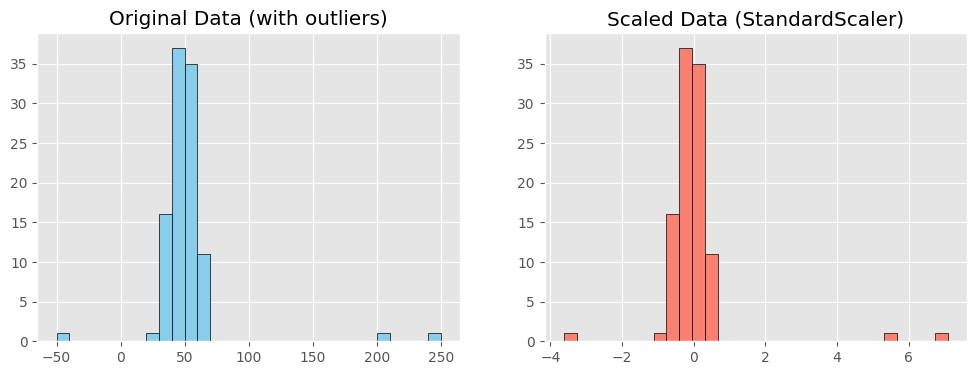

In [4]:
ss = StandardScaler()
X_ss = ss.fit_transform(X)
plot_comparison(X, X_ss, "StandardScaler")

## Visualizing RobustScaler

The RobustScaler focuses on the range where the central 50% of the data resides (IQR). This results in a scaling that is practically unaffected by the extreme outliers.

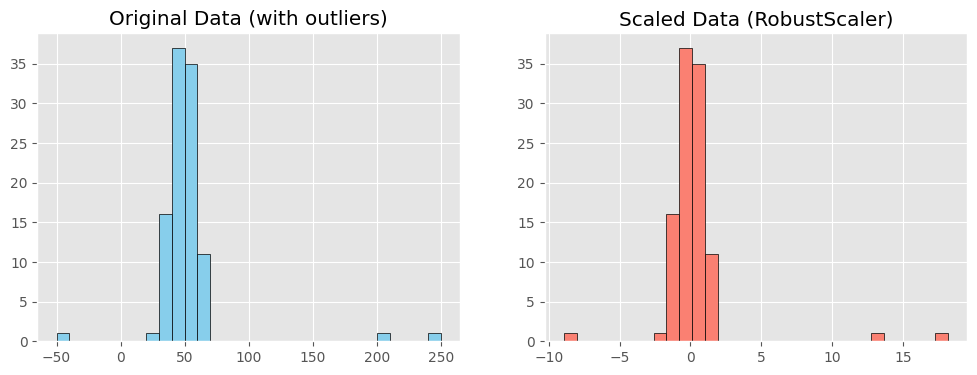

In [5]:
rs = RobustScaler()
X_rs = rs.fit_transform(X)
plot_comparison(X, X_rs, "RobustScaler")

## Persistence: Saving and Loading

In **sorix**, all serialized files use the `.sor` extension. You can save/load either the full object or just the internal state dictionary.

### A. Saving and Loading the Full Object (Recommended)

This is the easiest way as it preserves the class type and all internal logic.

In [6]:
# 1. Create and fit your scaler
scaler = StandardScaler()
scaler.fit(X)

# 2. Save the full object using the .sor extension
sorix.save(scaler, 'my_scaler.sor')

# 3. Load the object back
loaded_scaler = sorix.load('my_scaler.sor')

# Verify results
assert np.allclose(scaler.transform(X), loaded_scaler.transform(X))
print("Full scaler object successfully saved and loaded (.sor)!")

Full scaler object successfully saved and loaded (.sor)!


### B. Saving and Loading a `state_dict`

If you prefer to save only the learned parameters (like weights, means, or labels) for better cross-system interoperability or smaller file size, you can save the `state_dict` directly using `sorix.save`.

In [7]:
# 1. Get the state dictionary from the fitted scaler
params_dict = scaler.state_dict()

# 2. Save the dictionary using sorix.save with .sor extension
sorix.save(params_dict, 'scaler_params.sor')

# 3. Load the dictionary using sorix.load
loaded_params = sorix.load('scaler_params.sor')

# 4. Apply the loaded state to a fresh instance
new_scaler = StandardScaler()
new_scaler.load_state_dict(loaded_params)

# 5. Verify consistency
assert np.allclose(scaler.transform(X), new_scaler.transform(X))
print("Scaler state_dict successfully saved and loaded with sorix components!")

Scaler state_dict successfully saved and loaded with sorix components!
